In [1]:
import os, shutil
import random
import numpy as np
import pandas as pd
import cv2
import skimage
import matplotlib.pyplot as plt
import skimage.segmentation
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
from tqdm import tqdm

In [2]:

labels = ['Pneumonia', 'Normal', 'Covid19']
img_size = 224

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        img_files = os.listdir(path)

        print(f"\nLoading {label} ({len(img_files)} images)...")

        # tqdm hiển thị progress bar
        for img in tqdm(img_files):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
    return data
# Load data (only PNEUMONIA and NORMAL, COVID19 is excluded)
test = get_data("/kaggle/input/test-covid19-pneumonia-normal/Test_COVID19_Pneumonia_Normal/test")

# Trộn ảnh để tránh hiện tượng mô hình học theo thứ tự ảnh
test = shuffle(test, random_state=42)

# Đưa ảnh vào dạng NumPy - Reshape thành (N, 224, 224, 1) → ảnh grayscale 1 kênh
x_test = np.array([i[0] for i in test]).reshape(-1, img_size, img_size, 1)
y_test = np.array([i[1] for i in test])


# Normalize the pixel values to be between 0 and 1
x_test = x_test / 255.0

# Print shapes to verify everything is correct
print("data shape:", x_test.shape)
print("labels shape:", y_test.shape)

# Check class distribution
print("\nClass distribution in test set:")
print(f"PNEUMONIA: {np.sum(y_test == 0)}")
print(f"NORMAL: {np.sum(y_test == 1)}")
print(f"Covid19: {np.sum(y_test == 2)}")




Loading Pneumonia (1485 images)...


100%|██████████| 1485/1485 [00:23<00:00, 64.22it/s]



Loading Normal (1905 images)...


100%|██████████| 1905/1905 [00:27<00:00, 68.86it/s]



Loading Covid19 (630 images)...


100%|██████████| 630/630 [00:09<00:00, 69.32it/s]


data shape: (4020, 224, 224, 1)
labels shape: (4020,)

Class distribution in test set:
PNEUMONIA: 1485
NORMAL: 1905
Covid19: 630


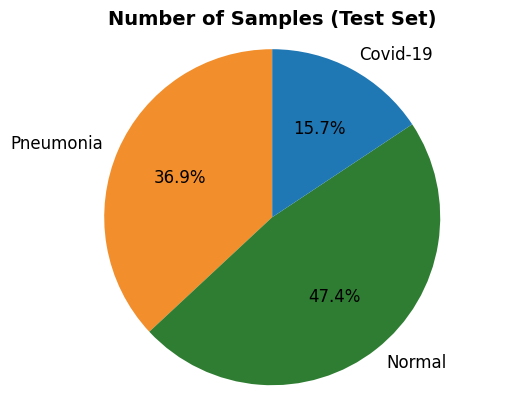

In [3]:
import matplotlib.pyplot as plt
import numpy as np

pneumonia_count = np.sum(y_test == 0)
normal_count    = np.sum(y_test == 1)
covid_count     = np.sum(y_test == 2)

labels = ['Pneumonia', 'Normal', 'Covid-19']
sizes = [pneumonia_count, normal_count, covid_count]

colors = ['#F28E2B', '#2E7D32', '#1F77B4']

fig, ax = plt.subplots()
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#ffffff')

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color': 'black', 'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_fontsize(12)

ax.set_title(
    'Number of Samples (Test Set)',
    fontsize=14,
    fontweight='bold',
    color='black'
)

ax.axis('equal')
plt.show()


# Vgg16

In [36]:
from tensorflow.keras.models import load_model

model_vgg16 = load_model("/kaggle/input/thanhtrung-cvck/best_model.h5")


In [37]:
from sklearn.metrics import accuracy_score

y_prob = model_vgg16.predict(x_test)

y_pred_vgg16 = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_test, y_pred_vgg16)

print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")


126/126 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step
Accuracy: 0.9694 (96.94%)


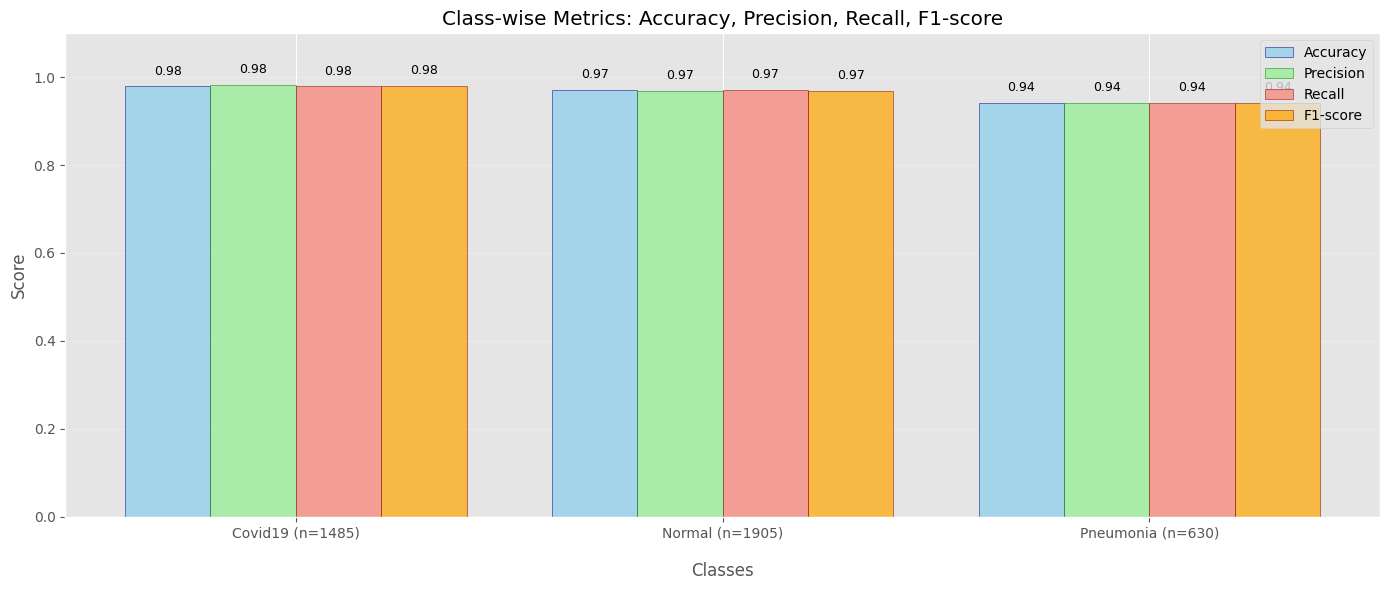

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def plot_classwise_metrics(y_true, y_pred, class_names):
    """
    Vẽ biểu đồ class-wise metrics: Accuracy, Precision, Recall, F1-score
    """
    n_classes = len(class_names)
    
    # Tính metrics cho từng lớp
    accuracies = []
    precisions = precision_score(y_true, y_pred, average=None, zero_division=0)
    recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_scores = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    class_counts = []
    for i in range(n_classes):
        class_mask = (y_true == i)
        class_pred = y_pred[class_mask]
        class_true = y_true[class_mask]
        acc = accuracy_score(class_true, class_pred) if len(class_true) > 0 else 0
        accuracies.append(acc)
        class_counts.append(len(class_true))
    
    # Vẽ biểu đồ
    x = np.arange(n_classes)
    width = 0.2  # độ rộng mỗi cột

    plt.figure(figsize=(14,6))
    plt.bar(x - 1.5*width, accuracies, width, label='Accuracy', color='skyblue', edgecolor='navy', alpha=0.7)
    plt.bar(x - 0.5*width, precisions, width, label='Precision', color='lightgreen', edgecolor='green', alpha=0.7)
    plt.bar(x + 0.5*width, recalls, width, label='Recall', color='salmon', edgecolor='darkred', alpha=0.7)
    plt.bar(x + 1.5*width, f1_scores, width, label='F1-score', color='orange', edgecolor='darkred', alpha=0.7)
    
    # Thêm nhãn giá trị lên từng cột
    for i in range(n_classes):
        plt.text(x[i] - 1.5*width, accuracies[i]+0.02, f'{accuracies[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] - 0.5*width, precisions[i]+0.02, f'{precisions[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + 0.5*width, recalls[i]+0.02, f'{recalls[i]:.2f}', ha='center', va='bottom', fontsize=9)
        plt.text(x[i] + 1.5*width, f1_scores[i]+0.02, f'{f1_scores[i]:.2f}', ha='center', va='bottom', fontsize=9)

    xtick_labels = [f"{name} (n={count})\n" for name, count in zip(class_names, class_counts)]
    plt.xticks(x, xtick_labels, rotation=0, ha='center')
    plt.ylim(0, 1.1)
    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title('Class-wise Metrics: Accuracy, Precision, Recall, F1-score')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return accuracies, precisions, recalls, f1_scores, class_counts

# Sử dụng:
accuracies, precisions, recalls, f1_scores, counts = plot_classwise_metrics(y_test, y_pred_vgg16, labels)

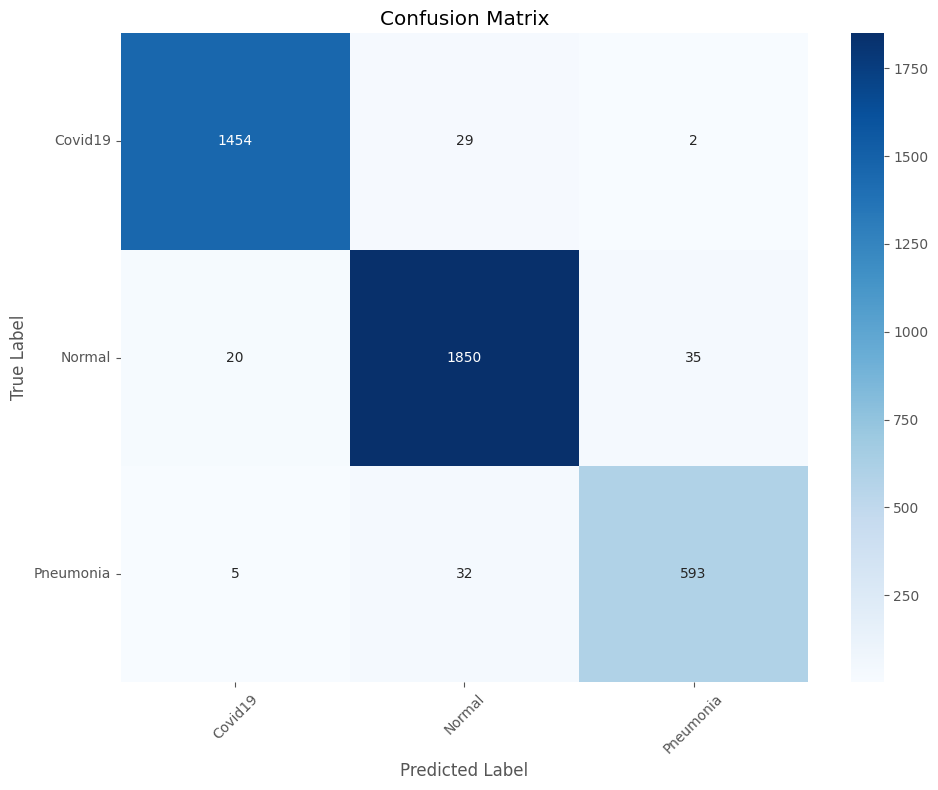

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Vẽ confusion matrix với heatmap"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(y_test, y_pred_vgg16, labels)

In [ ]:
# ResNet

In [40]:
from tensorflow.keras.models import load_model

model_ResNet = load_model("/kaggle/input/tvtrung-ckcv/best_model.h5")
# model.summary()

In [42]:
from sklearn.metrics import accuracy_score

y_prob_ResNet = model_ResNet.predict(x_test)

y_pred_ResNet = np.argmax(y_prob_ResNet, axis=1)

acc = accuracy_score(y_test, y_pred_ResNet)

print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")


126/126 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step
Accuracy: 0.9756 (97.56%)


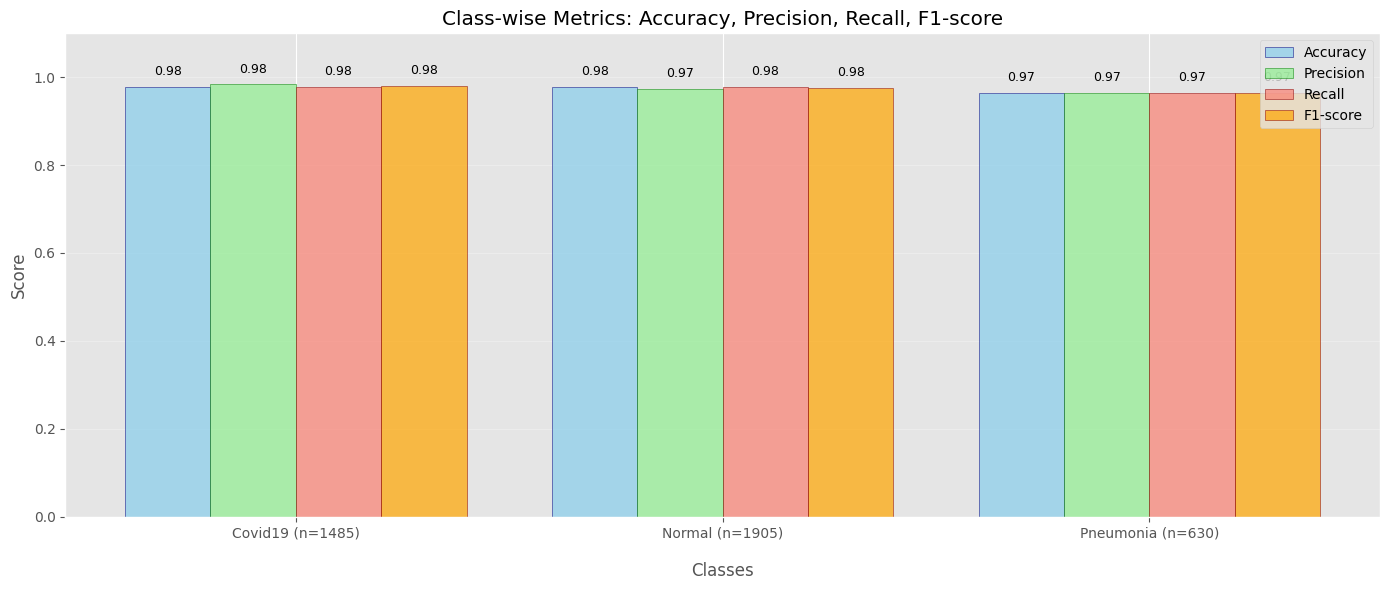

In [43]:
# Sử dụng:
accuracies, precisions, recalls, f1_scores, counts = plot_classwise_metrics(y_test, y_pred_ResNet, labels)

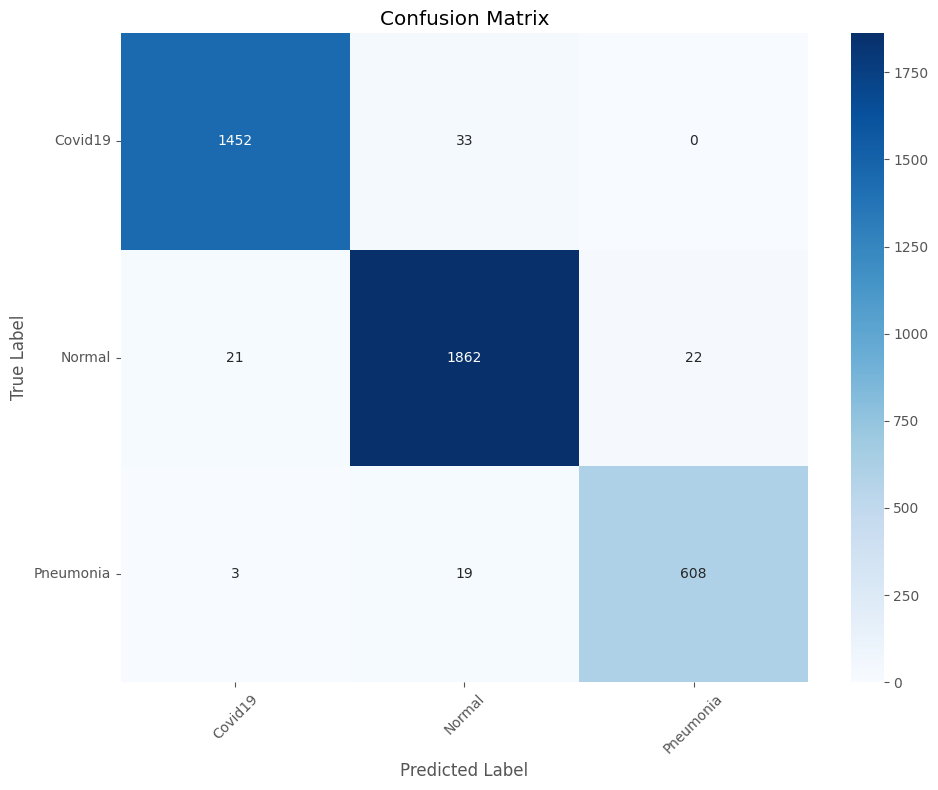

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Vẽ confusion matrix với heatmap"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(y_test, y_pred_ResNet, labels)

# densenet169

In [22]:
import os
import cv2
import numpy as np
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.densenet169(pretrained=True)

# Replace classifier
num_ftrs = model.classifier.in_features
model.classifier = nn.Linear(num_ftrs, 3)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


In [25]:
def evaluate(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"\n Test Accuracy: {accuracy:.4f}")

    return all_labels, all_preds

In [26]:
# Load model architecture
loaded_model = models.densenet169(pretrained=False)
num_ftrs = loaded_model.classifier.in_features
loaded_model.classifier = nn.Linear(num_ftrs, 3)   # correct final layer for DenseNet

# Load weights
loaded_model.load_state_dict(torch.load("/kaggle/input/densenet/pytorch/default/1/densenet169.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [27]:
def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is not None:
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error reading {img_path}: {e}")
    return data

In [30]:
class CovidDataset(Dataset):
    def __init__(self, data):
        self.x = np.array([i[0] for i in data])
        self.y = np.array([i[1] for i in data])

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.Lambda(lambda image: image.convert("RGB")),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        img = self.transform(img)
        label = torch.tensor(self.y[idx]).long()
        return img, label

In [31]:
test = shuffle(get_data("/kaggle/input/test-covid19-pneumonia-normal/Test_COVID19_Pneumonia_Normal/test"))

test_dataset = CovidDataset(test)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Test samples:", len(test_dataset))

Test samples: 4020


In [32]:
labels_test, preds_test = evaluate(loaded_model, test_loader)


 Test Accuracy: 0.9898


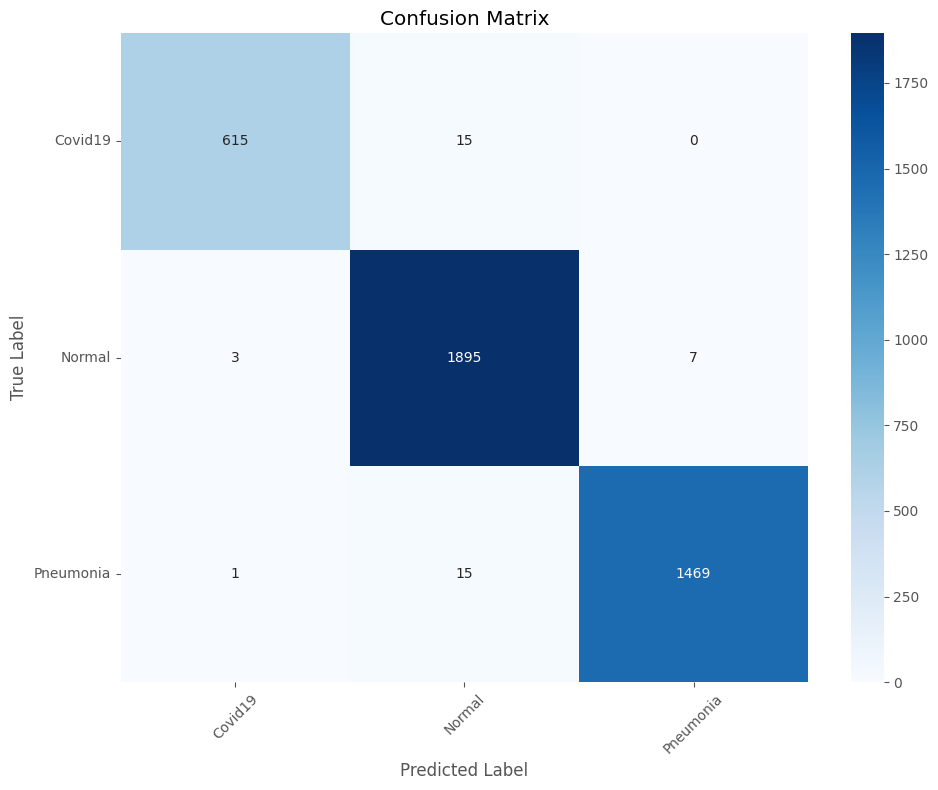

In [93]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Vẽ confusion matrix với heatmap"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(labels_test, preds_test, labels)

# Compute

In [81]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_metrics_single_model(
    y_true,
    y_pred,
    average="weighted"
):
    """
    Tính Accuracy, Precision, Recall, F1 cho 1 model
    """

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average=average, zero_division=0
    )
    recall    = recall_score(
        y_true, y_pred, average=average, zero_division=0
    )
    f1        = f1_score(
        y_true, y_pred, average=average, zero_division=0
    )

    return accuracy, precision, recall, f1


In [94]:
acc1, pre1, rec1, f11

(0.9694029850746269,
 0.9694253987275263,
 0.9694029850746269,
 0.9694115708474155)

In [82]:
acc1, pre1, rec1, f11 = compute_metrics_single_model(
    y_test, y_pred_vgg16
)

acc2, pre2, rec2, f12 = compute_metrics_single_model(
    y_test, y_pred_ResNet
)

acc3, pre3, rec3, f13 = compute_metrics_single_model(
    labels_test, preds_test
)


In [87]:
import matplotlib.pyplot as plt

def plot_metrics_3models(
    accuracies,
    precisions,
    recalls,
    f1_scores,
    model_names=None
):
    if model_names is None:
        model_names = ["Model 1", "Model 2", "Model 3"]

    metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

    plt.figure(figsize=(8, 5))

    for i, model in enumerate(model_names):
        scores = [
            accuracies[i],
            precisions[i],
            recalls[i],
            f1_scores[i]
        ]

        plt.plot(metrics, scores, marker='o', linewidth=2, label=model)

        for x, y in zip(metrics, scores):
            plt.text(
                x, y,
                f"{y:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.xlabel("Metrics")
    plt.ylabel("Score")
    plt.title("So sánh các metrics của 3 model")
    plt.ylim(0.8, 1.0)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


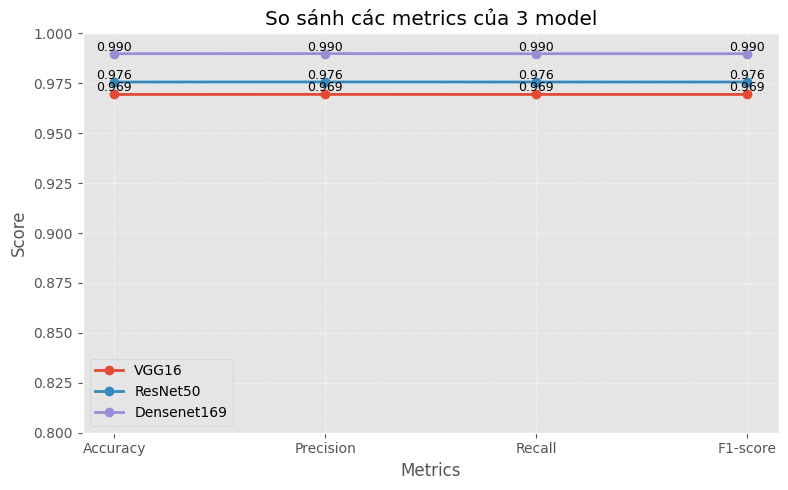

In [88]:
plot_metrics_3models(
    accuracies,
    precisions,
    recalls,
    f1_scores,
    model_names=["VGG16", "ResNet50","Densenet169"]
)
